# EDA and DATA cleaning

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.io as pio
import plotly.express as px
import matplotlib.pyplot as plt
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
pio.renderers.default = "notebook"

In [4]:
sns.set_style('darkgrid')

In [5]:
data=pd.read_csv(r'C:\projects\Telecom-Churn-Predictor\data\raw\Telecom_Churn.csv')

In [6]:
data.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [7]:
data.shape

(7043, 21)

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
data.drop(columns=['customerID'],inplace=True)

- colummn id is not help to the predcit the churn it is just an unique identifier for the customer.

In [10]:
cat_cols = [
    "gender","Partner","Dependents",
    "PhoneService","PaperlessBilling","Churn",
    "MultipleLines","TechSupport","StreamingTV",
    "OnlineBackup","DeviceProtection","StreamingMovies",
    "Contract","OnlineSecurity","InternetService",
    "PaymentMethod"
]

# convert to category
data[cat_cols] = data[cat_cols].astype("category")
data["SeniorCitizen"] = data["SeniorCitizen"].map({0:"No",1:"Yes"}).astype("category")
data['TotalCharges']=pd.to_numeric(data['TotalCharges'],errors='coerce')

---
category datatype is used for columns with few repeated values. It reduces memory usage and makes operations like groupby and filtering faster, improving overall performance for large datasets.

---

In [11]:
data.dtypes

gender              category
SeniorCitizen       category
Partner             category
Dependents          category
tenure                 int64
PhoneService        category
MultipleLines       category
InternetService     category
OnlineSecurity      category
OnlineBackup        category
DeviceProtection    category
TechSupport         category
StreamingTV         category
StreamingMovies     category
Contract            category
PaperlessBilling    category
PaymentMethod       category
MonthlyCharges       float64
TotalCharges         float64
Churn               category
dtype: object

In [12]:
round(data.describe(include='number'),2).T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80


In [13]:
data.describe(include='category').T

,count,unique,top,freq
gender,7043,2,Male,3555
SeniorCitizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [14]:
# for easier access to columns
data.columns = data.columns.str.lower()

In [15]:
data.isnull().sum().sum()

np.int64(11)

In [16]:
data.duplicated().sum()

np.int64(22)

In [17]:
data.dropna(inplace=True)

# EDA

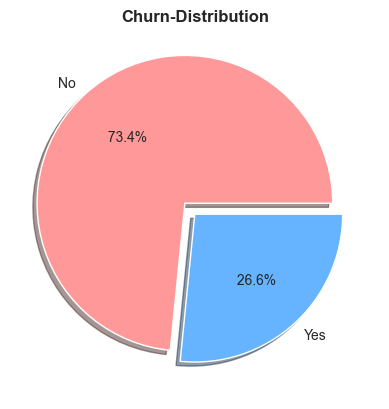

In [18]:
plt.pie(data['churn'].value_counts(),autopct='% 1.1f%%',labels=data['churn'].value_counts().index,shadow=True,explode=[0.1,0],colors=['#ff9999','#66b3ff'])
plt.title('Churn-Distribution',fontweight='bold')
plt.show()

- Data is imbalanced:-> we can use the `class_weight='balanced'` and also we can use the `smote` or `undersampling` or `oversampling` based on the best experiment and performance.

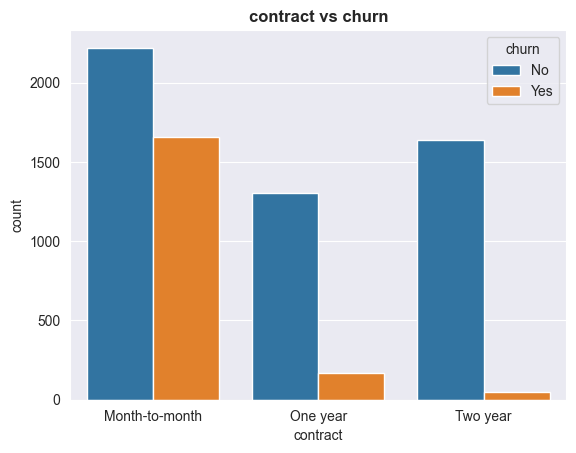

In [19]:
sns.countplot(data=data,x='contract',hue='churn')
plt.title('contract vs churn',fontweight='bold')
plt.show()

- `month-to-month` contract type has more churners means if the customer has month to month contract they are more likely to churn than other contract type.

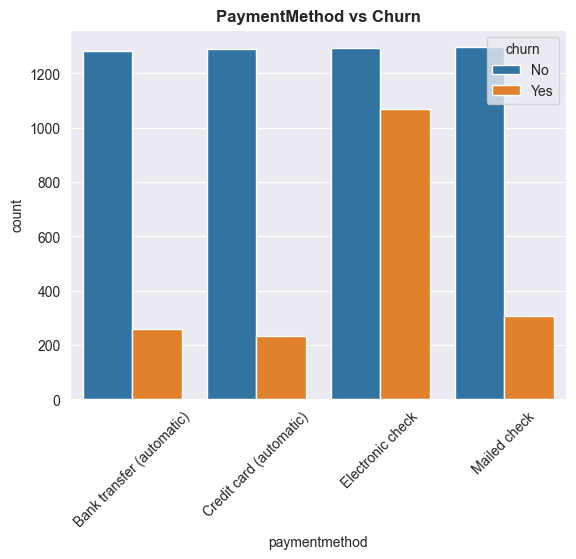

In [20]:
sns.countplot(data=data,x='paymentmethod',hue='churn')
plt.title('PaymentMethod vs Churn',fontweight='bold')
plt.xticks(rotation=45)
plt.show()

- here we can see that whose customer do the `electronics check` is more likely to churn than other payment method.

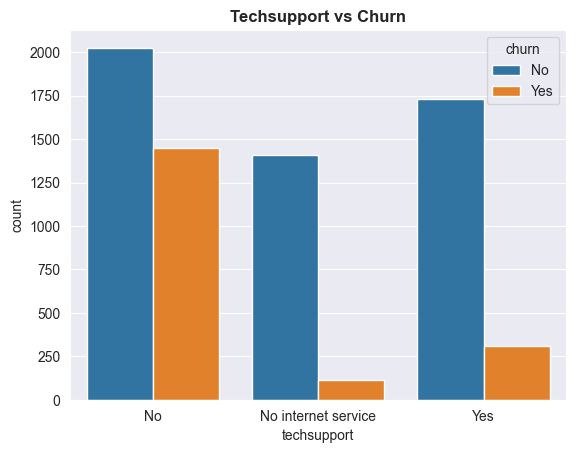

In [21]:
sns.countplot(data=data,x='techsupport',hue='churn')
plt.title('Techsupport vs Churn',fontweight='bold')
plt.show()

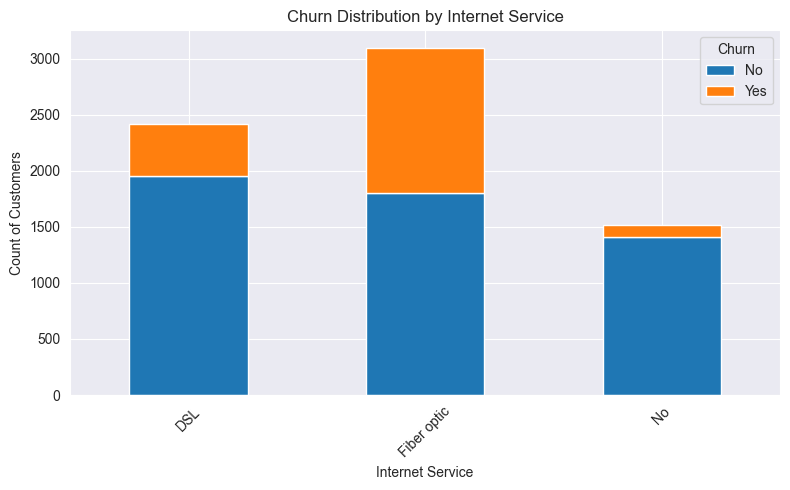

In [22]:
ct = pd.crosstab(data['internetservice'], data['churn'])
ct.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Churn Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Count of Customers")
plt.xticks(rotation=45)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

- whoever customer uses the `fiberoptic` service has more likely to churn than other.

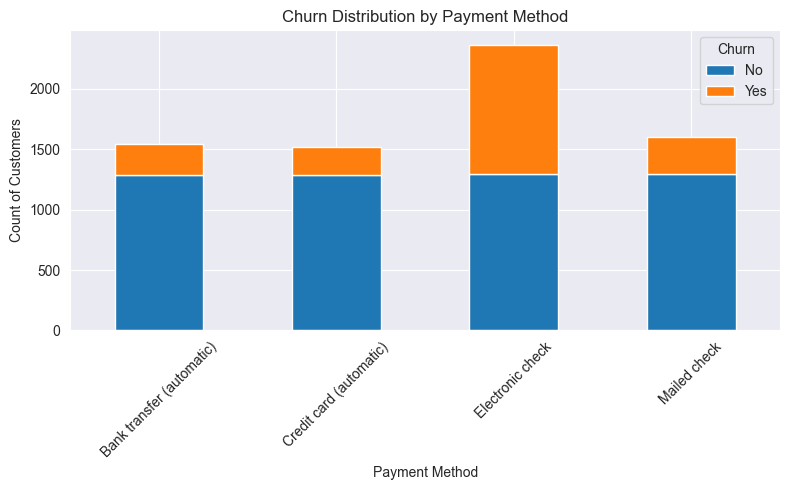

In [23]:
ct = pd.crosstab(data['paymentmethod'], data['churn'])
ct.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Churn Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count of Customers")
plt.xticks(rotation=45)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

- 100% bar chart is used when the category is not comparable based on the churn eg-> if the one bar is too big an another one is small in this situation we can not copare the percentage of churn that's why we uses this.

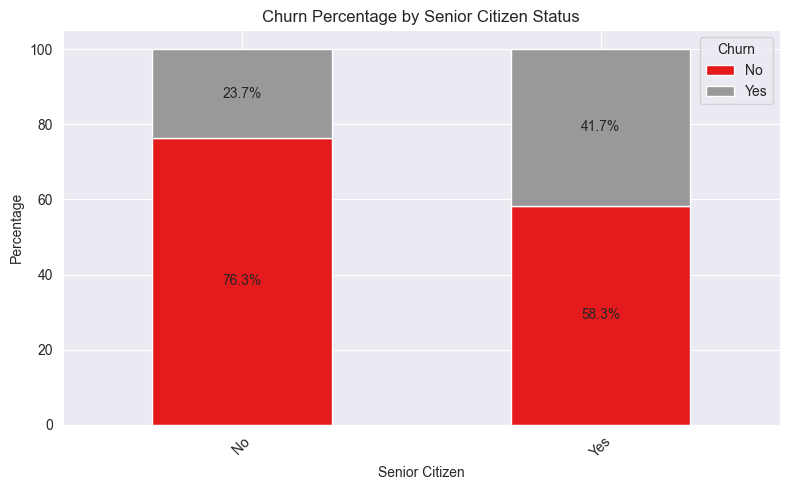

In [24]:
ct = pd.crosstab(data['seniorcitizen'], data['churn'], normalize='index') * 100
ax = ct.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set1')
# adding percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.title("Churn Percentage by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.legend(title="Churn")
plt.tight_layout()

plt.show()

---
- if the  Customer is `seniorcitizens (age greater than 60 almost)` than likely to churn than no. 
---

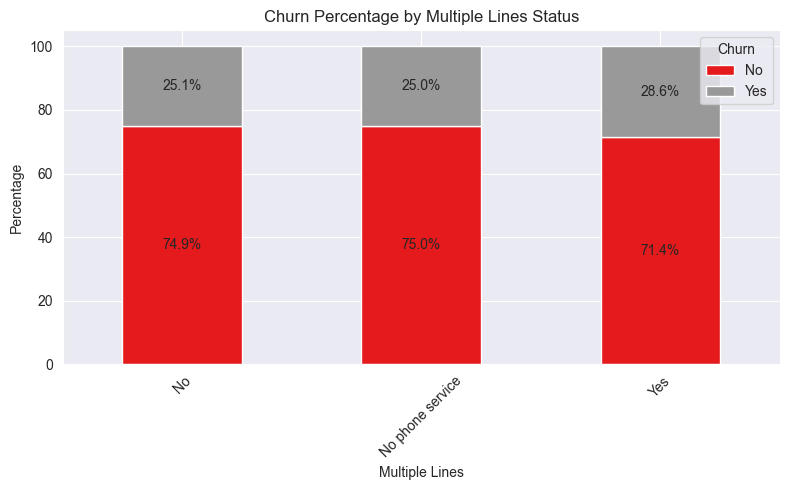

In [25]:
ct = pd.crosstab(data['multiplelines'], data['churn'], normalize='index') * 100
ax = ct.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set1')
# adding percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.title("Churn Percentage by Multiple Lines Status")
plt.xlabel("Multiple Lines")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.legend(title="Churn")
plt.tight_layout()

plt.show()

- here we can see that the ar'nt more impact of the `Multilines` columns.

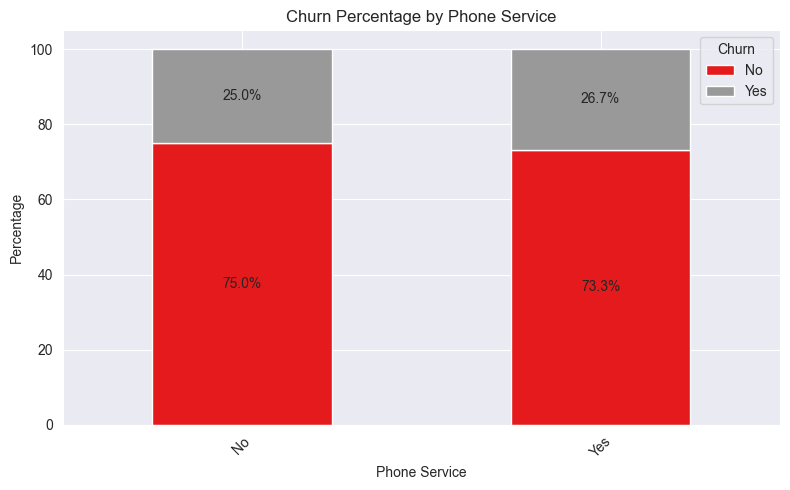

In [26]:
ct = pd.crosstab(data['phoneservice'], data['churn'], normalize='index') * 100
ax = ct.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Set1')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')
plt.title("Churn Percentage by Phone Service")
plt.xlabel("Phone Service")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Churn")
plt.tight_layout()

plt.show()

whoever uses the phoneservices is more likely to churn than who don't.

In [33]:
data.columns

Index(['gender', 'seniorcitizen', 'partner', 'dependents', 'tenure',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod',
       'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

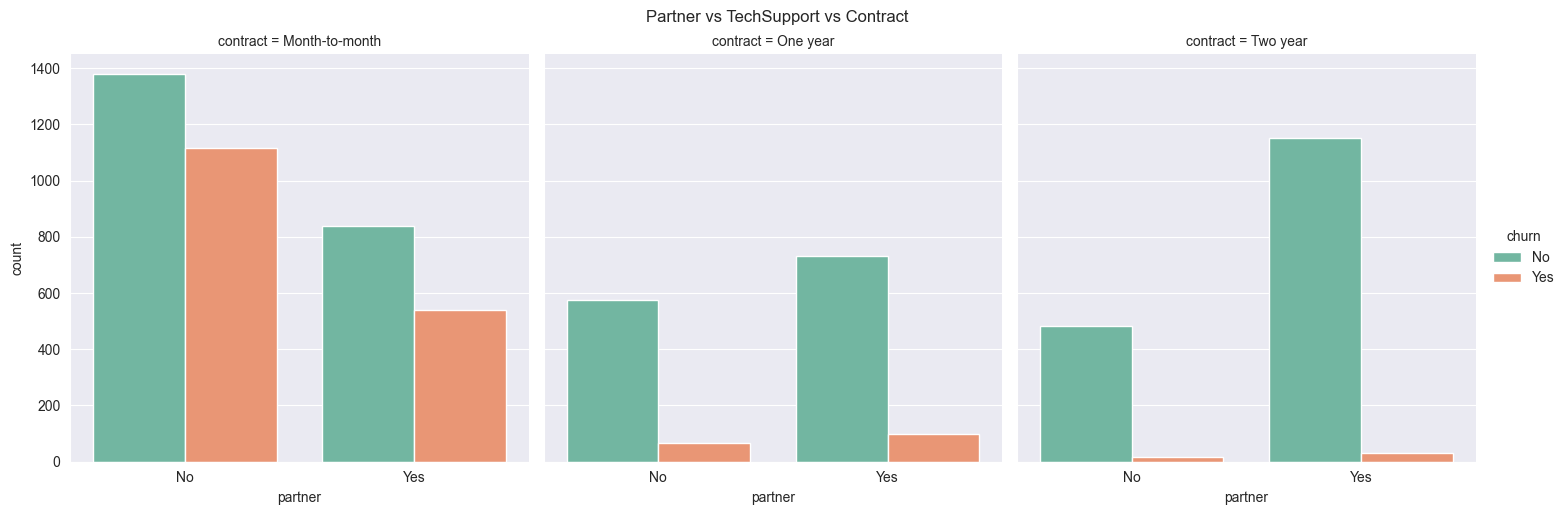

In [ ]:
ct = data.groupby(['partner', 'churn', 'contract']).size().reset_index(name='count')
sns.catplot(data=ct, x='partner', y='count', 
            hue='churn', col='contract',  
            kind='bar', palette='Set2')
plt.suptitle('Partner vs churn vs Contract', y=1.02)
plt.show()

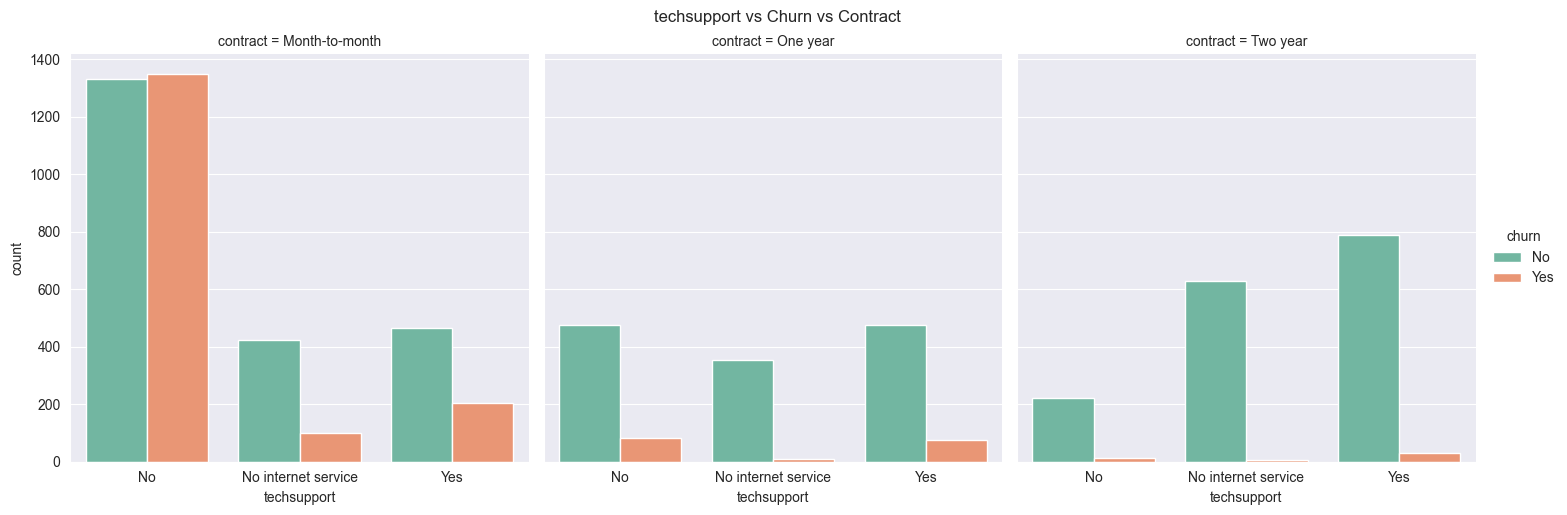

In [47]:
ct = data.groupby(['techsupport', 'churn', 'contract']).size().reset_index(name='count')
sns.catplot(data=ct, x='techsupport', y='count', 
            hue='churn', col='contract',  
            kind='bar', palette='Set2')
plt.suptitle('techsupport vs Churn vs Contract', y=1.02)
plt.show()

In [ ]:
ct = data.groupby(['techsupport', 'churn', 'contract']).size().reset_index(name='count')
sns.catplot(data=ct, x='techsupport', y='count', 
            hue='churn', col='contract',  
            kind='bar', palette='Set2')
plt.suptitle('techsupport vs Churn vs Contract', y=1.02)
plt.show()

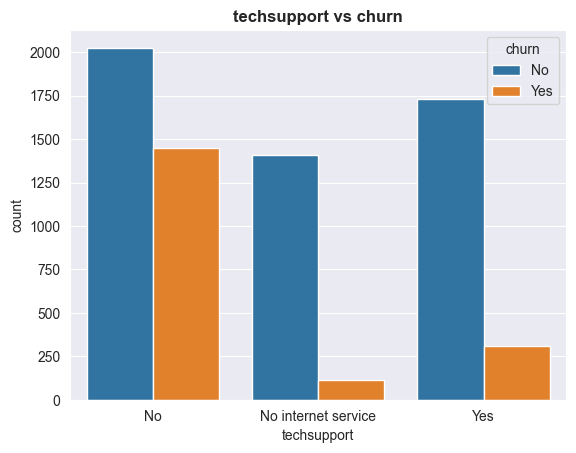

In [38]:
sns.countplot(data=data,x='techsupport',hue='churn')
plt.title('techsupport vs churn',fontweight='bold')
plt.show()

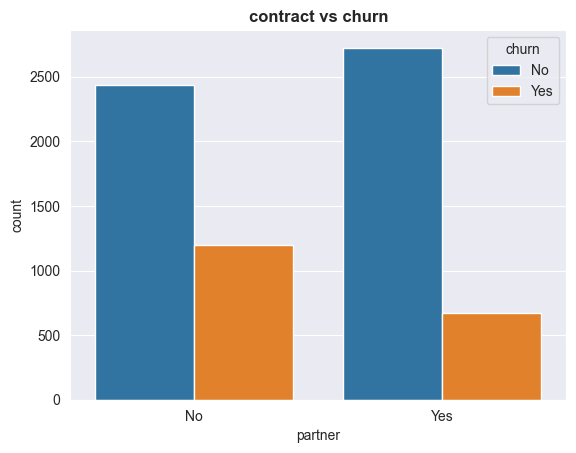

In [36]:
sns.countplot(data=data,x='partner',hue='churn')
plt.title('contract vs churn',fontweight='bold')
plt.show()

In [27]:
numeric_cols=data.select_dtypes(include='number').columns
numeric_cols

Index(['tenure', 'monthlycharges', 'totalcharges'], dtype='str')

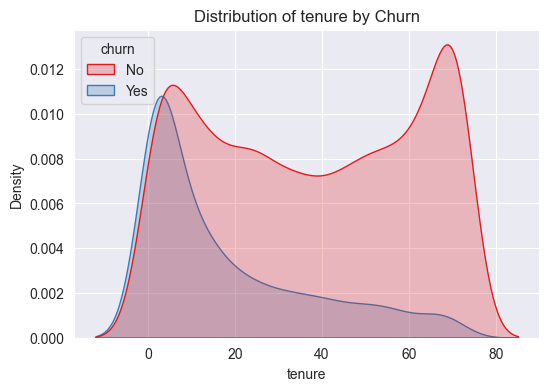

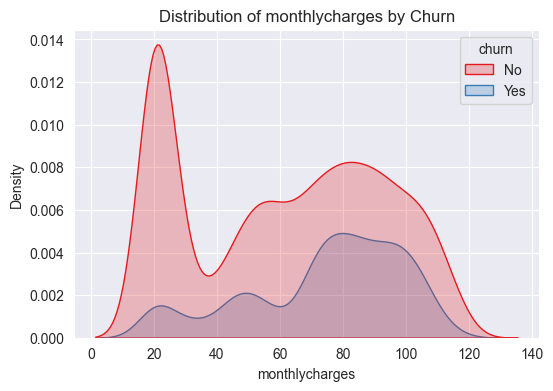

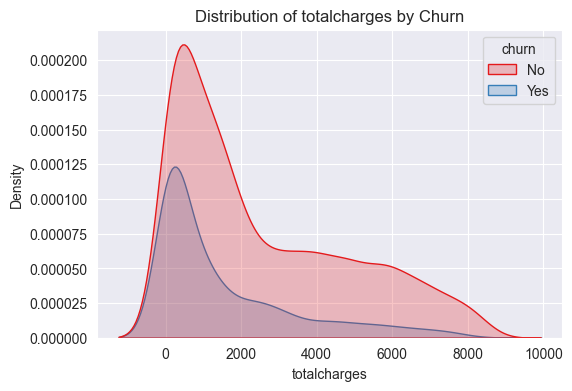

In [29]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=data, x=col, hue='churn', fill=True, palette='Set1')
    plt.title(f"Distribution of {col} by Churn")
    plt.show()

- `tenure->`:Customers with short tenure show a higher probability of churn, while customers who stay longer with the company tend to have a lower churn rate.
- `monthly-charges->` Customers with higher monthly charges (around 70–100) show a higher tendency to churn compared to customers with lower monthly charges.
- `totalcharges->` Customers with lower total charges show a higher churn tendency, while customers with higher total charges are less likely to churn, indicating that long-term or high-value customers tend to remain loyal.

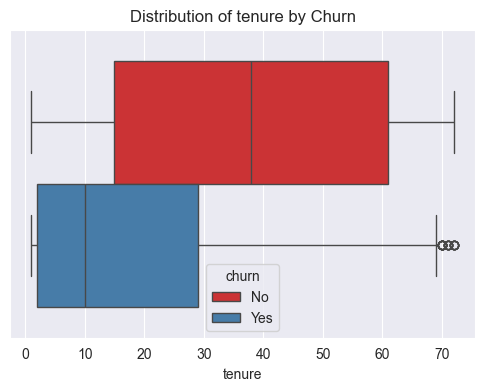

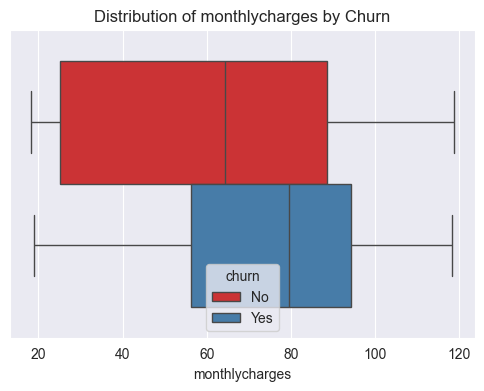

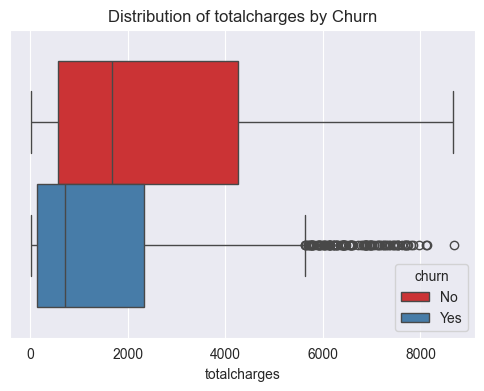

In [30]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=data, x=col, hue='churn', fill=True, palette='Set1')
    plt.title(f"Distribution of {col} by Churn")
    plt.show()

In [32]:
fig=px.scatter_3d(data,x='tenure',y='monthlycharges',z='totalcharges',size='totalcharges',color='churn',title='the relatio of tenure monthlycharegs and totalcharges by churn',template='plotly_dark')
fig.show()

---
- ustomers with higher tenure and monthly charges have higher total charges. Churn customers tend to have lower tenure (not necessarily lower monthly charges) compared to non-churn customers — meaning they leave early before accumulating high total charges. In fact, high monthly charges with low tenure can be a churn risk signal.
---

<Axes: xlabel='tenure', ylabel='monthlycharges'>

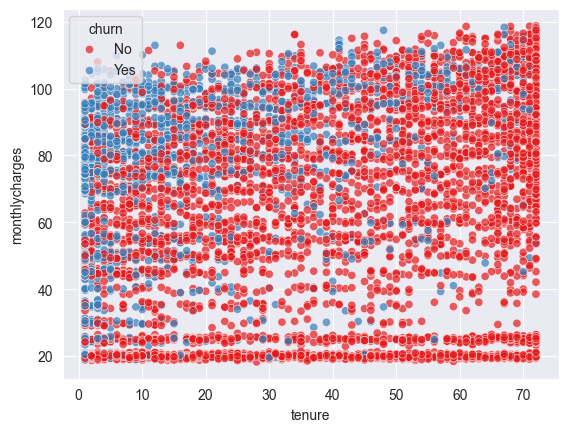

In [50]:
sns.scatterplot(data=data,x='tenure',y='monthlycharges',hue='churn',palette='Set1',alpha=0.7)

# feature eng. & feature construction.